# Phân tích Khám phá Dữ liệu (Exploratory Data Analysis - EDA)

Trong Notebook này, chúng ta sẽ phân tích dữ liệu chất lượng không khí thông qua lăng kính **Data Storytelling**. Câu chuyện sẽ đi từ bức tranh toàn cảnh của cả nước, phân tích biến động theo thời gian, cho đến những so sánh giữa các vùng miền để tìm ra nguyên nhân chính gây suy giảm chất lượng không khí.

**Cấu trúc câu chuyện:**
1. **Chương 1:** Bức tranh Toàn cảnh (Overview) - Việt Nam đang thở bầu không khí như thế nào?
2. **Chương 2:** Nhịp đập Thời gian (Temporal Trends) - Lúc nào là thời điểm nguy hiểm nhất?
3. **Chương 3:** Phân tích Vùng miền (Regional Analysis) - Nơi nào ô nhiễm nhất?
4. **Chương 4:** Truy tìm Thủ phạm (Pollutant Correlation) - Chất nào quyết định chỉ số AQI?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dữ liệu ĐÃ ĐƯỢC LÀM SẠCH từ Bước 2
file_path = '../data/cleaned/vietnam_air_quality_dataset_cleaned.csv'
print("Đang đọc dữ liệu sạch...")
df = pd.read_csv(file_path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f"Kích thước bộ dữ liệu: {df.shape}")
df.head()


Đang đọc dữ liệu sạch...
Kích thước bộ dữ liệu: (1388016, 18)


,Timestamp,Code,Province,Region,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Dust,Year,Month,Day,Hour,DayOfWeek,AQI_Level
0,2024-01-01 00:00:00,51,An Giang,Miền Nam,57,28.6,44.1,392.0,10.1,13.7,58.0,0.0,2024,1,1,0,0,Trung Bình
1,2024-01-01 01:00:00,51,An Giang,Miền Nam,56,23.9,37.5,348.0,9.6,12.8,53.0,0.0,2024,1,1,1,0,Trung Bình
2,2024-01-01 02:00:00,51,An Giang,Miền Nam,55,19.7,31.2,315.0,9.5,11.8,48.0,0.0,2024,1,1,2,0,Trung Bình
3,2024-01-01 03:00:00,51,An Giang,Miền Nam,54,16.5,26.5,291.0,9.6,10.7,42.0,0.0,2024,1,1,3,0,Trung Bình
4,2024-01-01 04:00:00,51,An Giang,Miền Nam,51,14.7,23.2,290.0,10.2,10.3,38.0,0.0,2024,1,1,4,0,Trung Bình


## Chương 1: Bức tranh Toàn cảnh (Overview)
*Nhìn chung, chất lượng không khí của Việt Nam trong năm qua đang ở mức nào? Đa số thời gian chúng ta được hít thở không khí trong lành hay phải đối mặt với khói bụi?*


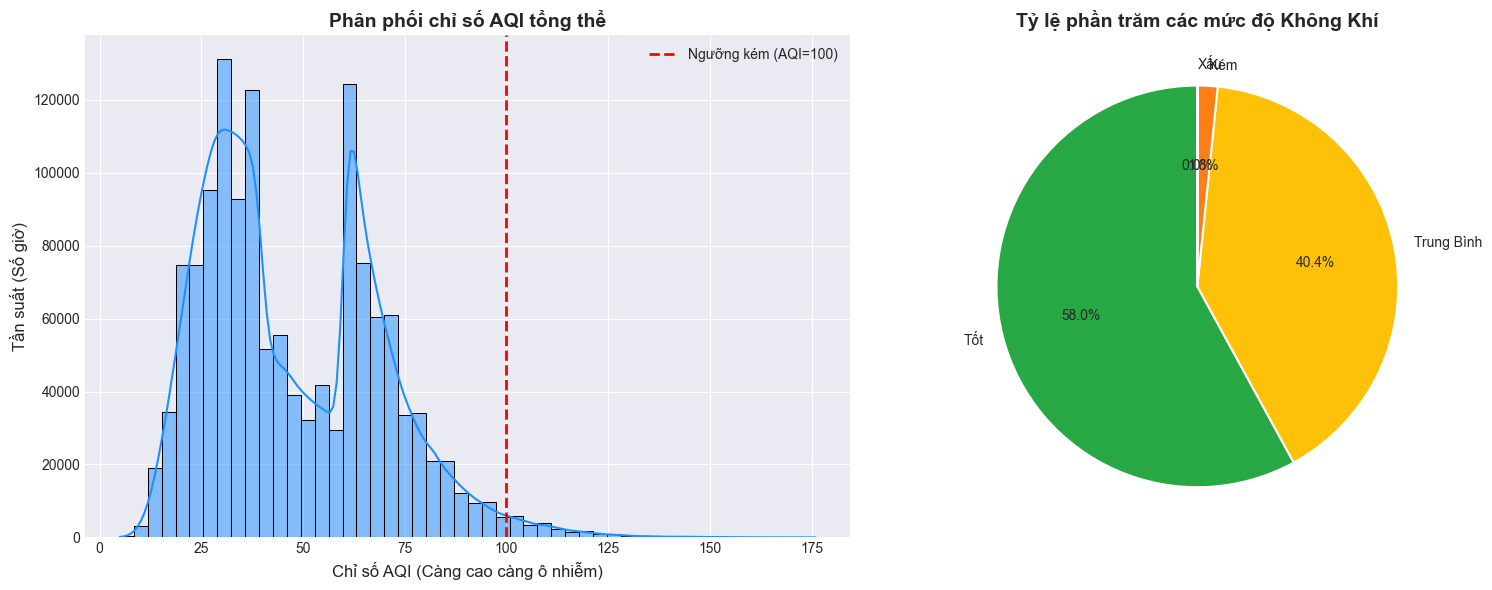

In [2]:
# Tạo Figure chứa 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: HISTOGRAM PHÂN PHỐI AQI ---
sns.histplot(df['AQI'], bins=50, kde=True, ax=axes[0], color='dodgerblue')
axes[0].set_title('Phân phối chỉ số AQI tổng thể', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Chỉ số AQI (Càng cao càng ô nhiễm)', fontsize=12)
axes[0].set_ylabel('Tần suất (Số giờ)', fontsize=12)

# Thêm đường kẻ giới hạn WHO (Ví dụ: AQI > 100 là kém)
axes[0].axvline(100, color='red', linestyle='--', linewidth=2, label='Ngưỡng kém (AQI=100)')
axes[0].legend()

# --- BIỂU ĐỒ 2: PIE CHART TỶ LỆ CÁC MỨC ĐỘ AQI ---
# Đếm số lượng theo Level
aqi_counts = df['AQI_Level'].value_counts()
# Sắp xếp lại thứ tự cho chuẩn mức độ
level_order = ['Tốt', 'Trung Bình', 'Kém', 'Xấu', 'Rất Xấu', 'Nguy Hại']
aqi_counts = aqi_counts.reindex([x for x in level_order if x in aqi_counts.index])

# Màu sắc chuẩn hóa như trên Dashboard UI
colors = ['#28a745', '#ffc107', '#fd7e14', '#dc3545', '#6f42c1', '#780000']

axes[1].pie(aqi_counts.values, labels=aqi_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Tỷ lệ phần trăm các mức độ Không Khí', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


**Phân tích Thống kê Cấu trúc Phân phối Chỉ số AQI Tổng thể**

**1. Phân tích Phân phối Tần suất (Biểu đồ Histogram):**
*   **Đặc trưng phân phối:** Đồ thị tần suất chỉ số AQI thể hiện rõ tính chất phân phối lệch phải. Đuôi phân phối kéo dài về phía các giá trị AQI > 100, minh chứng cho việc các sự kiện ô nhiễm nghiêm trọng tuy có xảy ra nhưng tần suất rất thấp.
*   **Đặc tính đa đỉnh:** Đường cong ước lượng mật độ hạt nhân chỉ ra đây là một phân phối đa đỉnh. Dữ liệu tập trung hình thành hai cực đại chính: cực đại thứ nhất nằm trong khoảng AQI từ 25 - 40, cực đại thứ hai ở khoảng AQI = 60. Đặc tính đa đỉnh này gợi ý giả thuyết về sự tồn tại của hai hoặc nhiều quần thể dữ liệu có đặc tính khác biệt bị trộn lẫn (ví dụ: sự sai khác về AQI giữa ban ngày/ban đêm, mùa mưa/mùa khô, hoặc khu vực thành thị/nông thôn).
*   **Ngưỡng an toàn:** Diện tích phần nằm bên trái đường tham chiếu (AQI = 100) chiếm tỷ trọng áp đảo, xác nhận hầu hết các giá trị quan trắc đều tuân thủ tiêu chuẩn an toàn cơ bản.

**2. Phân tích Tỷ trọng Phân cấp (Biểu đồ Pie Chart):**
*   **Mức độ tập trung:** Dữ liệu cho thấy sự tập trung cao độ vào hai phân cấp chất lượng không khí thấp nhất. Cụ thể, phân cấp "Tốt" (AQI $\le$ 50) chiếm ưu thế tuyệt đối với 58.0% tổng số quan trắc, theo sau là phân cấp "Trung bình" (50 < AQI $\le$ 100) với tỷ trọng 40.4%.
*   **Tỷ lệ rủi ro:** Khối lượng dữ liệu vượt ngưỡng an toàn (AQI > 100) có ý nghĩa thống kê rất nhỏ. Phân cấp "Kém" chỉ ghi nhận mức 1.6%, trong khi phân cấp "Xấu" gần như xấp xỉ 0%. 
*   **Kết luận:** Dữ liệu định lượng cho thấy 98.4% tổng thời gian quan trắc trên toàn hệ thống duy trì ở mức chất lượng không khí từ Trung bình trở lên, phản ánh độ ổn định và mức độ an toàn cao của chất lượng không khí tổng quát trong chu kỳ thu thập dữ liệu.


## Chương 2: Nhịp đập Thời gian (Temporal Trends)
*Chất lượng không khí không hề tĩnh lặng mà thay đổi liên tục theo quy luật sinh hoạt của con người. Vậy trong 1 ngày và trong 1 tuần, khi nào là thời điểm bụi bặm nhất?*


C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_23584\403036702.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='AQI', data=weekly_trend, ax=axes[1], palette='viridis')
C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_23584\403036702.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(days)


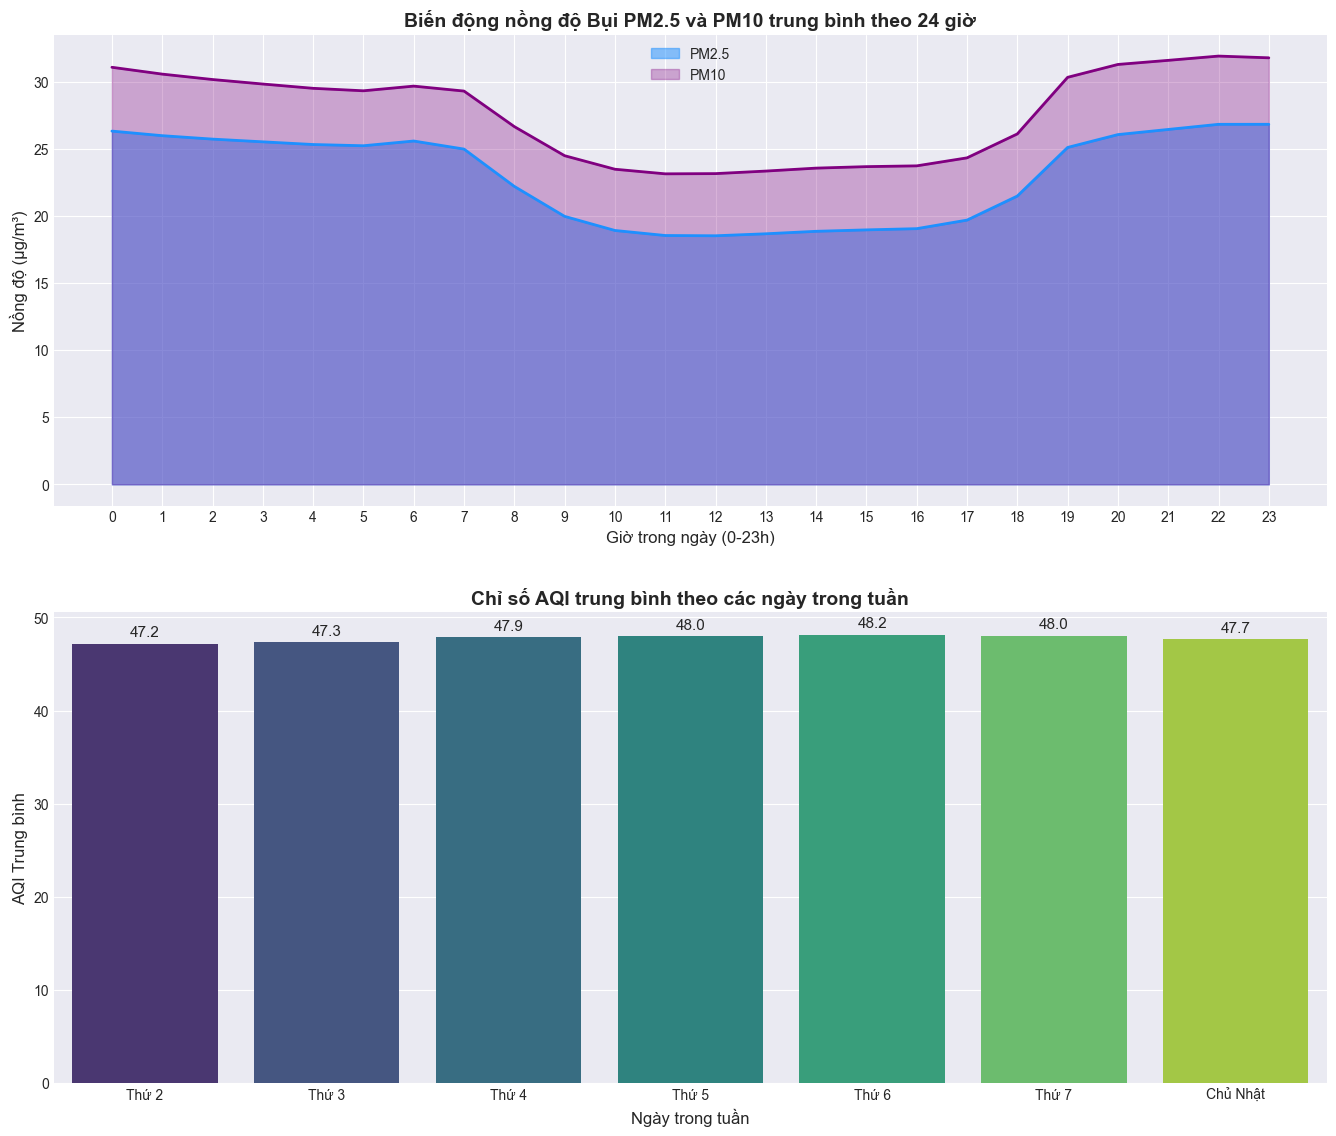

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- BIỂU ĐỒ 3: DIỄN BIẾN NỒNG ĐỘ THEO GIỜ TRONG NGÀY ---
# Tính trung bình theo giờ
hourly_trend = df.groupby('Hour')[['PM2.5', 'PM10']].mean().reset_index()

# Dùng Area Chart để giống với UI Dashboard
axes[0].fill_between(hourly_trend['Hour'], hourly_trend['PM2.5'], alpha=0.5, color='dodgerblue', label='PM2.5')
axes[0].fill_between(hourly_trend['Hour'], hourly_trend['PM10'], alpha=0.3, color='purple', label='PM10')
axes[0].plot(hourly_trend['Hour'], hourly_trend['PM2.5'], color='dodgerblue', linewidth=2)
axes[0].plot(hourly_trend['Hour'], hourly_trend['PM10'], color='purple', linewidth=2)

axes[0].set_title('Biến động nồng độ Bụi PM2.5 và PM10 trung bình theo 24 giờ', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giờ trong ngày (0-23h)', fontsize=12)
axes[0].set_ylabel('Nồng độ (µg/m³)', fontsize=12)
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# --- BIỂU ĐỒ 4: AQI THEO NGÀY TRONG TUẦN ---
# Tính trung bình AQI theo thứ trong tuần
weekly_trend = df.groupby('DayOfWeek')['AQI'].mean().reset_index()
days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']

sns.barplot(x='DayOfWeek', y='AQI', data=weekly_trend, ax=axes[1], palette='viridis')
axes[1].set_xticklabels(days)
axes[1].set_title('Chỉ số AQI trung bình theo các ngày trong tuần', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ngày trong tuần', fontsize=12)
axes[1].set_ylabel('AQI Trung bình', fontsize=12)

# Ghi chú giá trị lên đầu cột
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11)

plt.tight_layout(pad=3.0)
plt.show()


**Phân tích Thống kê Biến động Không gian - Thời gian**

**1. Khảo sát Chu kỳ Biến thiên Trong ngày (Biểu đồ Area Chart):**
*   **Mô hình đa đỉnh:** Đồ thị chuỗi thời gian nồng độ PM2.5 và PM10 trong 24 giờ thể hiện rõ cấu trúc phân phối hai cực đại. 
    *   **Cực đại thứ nhất (Biên độ sáng):** Xuất hiện vào khoảng thời gian từ 07:00 đến 09:00. Nồng độ bắt đầu gia tăng từ 06:00 và đạt đỉnh điểm tương quan thuận với thời gian bắt đầu các hoạt động nhân sinh vành đai đô thị (chu kỳ giao thông buổi sáng).
    *   **Cực tiểu (Biên độ trưa - chiều):** Nồng độ các chất ô nhiễm duy trì ở mức thấp nhất trong khoảng từ 10:00 đến 17:00. Sự suy giảm này có thể được lý giải bởi sự gia tăng độ cao lớp biên hành tinh do bức xạ nhiệt mặt trời, tạo điều kiện thuận lợi cho sự khuếch tán không khí theo phương thẳng đứng.
    *   **Cực đại thứ hai (Biên độ tối - đêm):** Nồng độ gia tăng đột ngột sau 18:00 và duy trì ở mức cao xuyên suốt đêm. Hiện tượng này thường gắn liền với sự nghịch nhiệt bức xạ vào ban đêm, làm ức chế quá trình đối lưu và "nhốt" các chất ô nhiễm ở tầng thấp.
*   **Tương quan động lực học:** Sự hội tụ về hình thái đồ thị giữa PM2.5 và PM10 cho thấy độ tương quan cực kỳ chặt chẽ giữa hai loại hạt này, chỉ ra rằng chúng có chung nguồn phát thải (chủ yếu từ khí thải đốt trong và bụi lơ lửng cơ học).

**2. Khảo sát Chu kỳ Biến thiên Trong tuần (Biểu đồ Bar Chart):**
*   **Độ phân tán dữ liệu:** Phân tích phương sai trung bình chỉ số AQI giữa các ngày trong tuần cho thấy mức độ biến động là không đáng kể (dao động trong biên độ hẹp từ 47.2 đến 48.2).
*   **Phân tích xu hướng:** Mặc dù biên độ rất nhỏ, dữ liệu vẫn ghi nhận một xu hướng tăng tịnh tiến nhẹ từ đầu tuần (Thứ 2: 47.2) đến cuối tuần làm việc (Thứ 6: 48.2) và bắt đầu suy giảm nhẹ vào các ngày nghỉ (Chủ Nhật: 47.7). 
*   **Kết luận:** Trái với giả thuyết thông thường về sự chênh lệch lớn giữa ngày làm việc và ngày nghỉ, dữ liệu định lượng chứng minh rằng mức nền ô nhiễm được duy trì khá đồng đều trong suốt tuần. Sự chênh lệch phương sai giữa các ngày chưa đủ lớn để tạo ra ý nghĩa thống kê quyết định, cho thấy các nguồn phát thải duy trì hoạt động với cường độ tương đối ổn định.


## Chương 3: Phân tích Vùng miền (Regional Analysis)
*Quốc gia hình chữ S trải dài trên nhiều vĩ độ. Liệu chất lượng không khí ở Miền Bắc, Miền Trung và Miền Nam có sự phân hóa như thế nào? Nơi nào đang là "điểm nóng" về ô nhiễm bụi mịn?*


C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_23584\4219961982.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='AQI', data=df, ax=axes[0], palette='Set2')


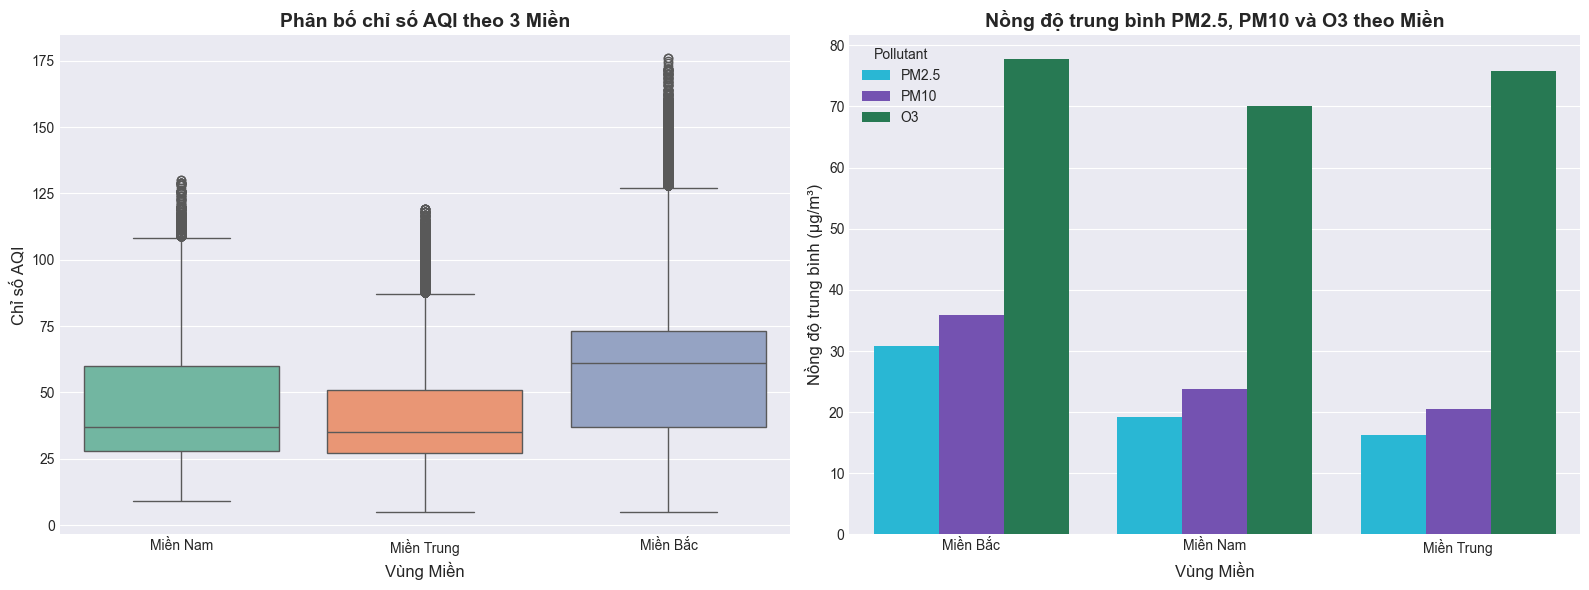

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 5: BOXPLOT AQI THEO MIỀN ---
# Dùng Boxplot để xem độ phân tán và các điểm ngoại lệ (Outliers) của các vùng
sns.boxplot(x='Region', y='AQI', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Phân bố chỉ số AQI theo 3 Miền', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Vùng Miền', fontsize=12)
axes[0].set_ylabel('Chỉ số AQI', fontsize=12)

# --- BIỂU ĐỒ 6: SO SÁNH NỒNG ĐỘ PM2.5, PM10, O3 THEO MIỀN ---
# Tính nồng độ trung bình
regional_mean = df.groupby('Region')[['PM2.5', 'PM10', 'O3']].mean().reset_index()
# Chuyển đổi (Melt) DataFrame để vẽ Grouped Bar Chart bằng Seaborn
regional_melted = pd.melt(regional_mean, id_vars=['Region'], value_vars=['PM2.5', 'PM10', 'O3'], 
                          var_name='Pollutant', value_name='Concentration')

sns.barplot(x='Region', y='Concentration', hue='Pollutant', data=regional_melted, ax=axes[1], palette=['#0dcaf0', '#6f42c1', '#198754'])
axes[1].set_title('Nồng độ trung bình PM2.5, PM10 và O3 theo Miền', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Vùng Miền', fontsize=12)
axes[1].set_ylabel('Nồng độ trung bình (µg/m³)', fontsize=12)

plt.tight_layout()
plt.show()


**Phân tích Thống kê Không gian về Phân bố Chất lượng Không khí (Regional Analysis)**

**1. Phân tích Độ phân tán và Khuynh hướng tập trung (Biểu đồ Boxplot):**
*   **Khuynh hướng hướng tâm:** Trung vị của chỉ số AQI ghi nhận sự chênh lệch có ý nghĩa thống kê giữa 3 vùng sinh thái. Miền Bắc có mức trung vị cao nhất (khoảng 60), theo sau là Miền Nam (khoảng 37) và Miền Trung có mức trung vị thấp nhất (khoảng 35).
*   **Độ phân tán dữ liệu:** Dải phân vị của Miền Bắc rộng nhất, cho thấy phương sai của tập dữ liệu tại khu vực này rất lớn, phản ánh mức độ biến động chất lượng không khí cao. Ngược lại, Miền Trung có độ phân tán hẹp nhất, cho thấy chất lượng không khí duy trì trạng thái đồng nhất và ổn định hơn.
*   **Phân tích điểm dị biệt:** Đồ thị boxplot của Miền Bắc xuất hiện một chuỗi dày đặc các điểm ngoại lai kéo dài lên đến tiệm cận giá trị 175. Điều này minh chứng cho sự tồn tại của các đợt ô nhiễm cục bộ cường độ cao với tần suất xuất hiện lớn hơn đáng kể so với Miền Nam và Miền Trung.

**2. Phân tích Cơ cấu Chất ô nhiễm theo Không gian (Biểu đồ Grouped Bar Chart):**
*   **Sự phân hóa của Vật chất hạt:** Cấu trúc nồng độ bụi mịn PM2.5 và PM10 thể hiện sự phân hóa không gian sâu sắc. Nồng độ trung bình của cả hai loại hạt này tại Miền Bắc cao vượt trội (PM2.5 > 30 µg/m³ và PM10 > 35 µg/m³), cao gấp xấp xỉ 1.5 đến 2 lần so với nồng độ tương ứng tại Miền Trung và Miền Nam.
*   **Độ đồng nhất của Khí O3:** Khác biệt với bụi mịn, nồng độ O3 thể hiện mức nền khá đồng nhất và duy trì ở mức cao (từ 70 đến 80 µg/m³) trên phạm vi toàn quốc.
*   **Kết luận định lượng:** Sự chênh lệch phương sai và trung vị AQI giữa các vùng miền (quan sát từ Boxplot) có nguồn gốc trực tiếp từ sự khác biệt có ý nghĩa thống kê về nồng độ vật chất hạt (PM2.5, PM10). Dữ liệu chỉ ra rằng đặc thù ô nhiễm tại Miền Bắc mang tính chất ô nhiễm bụi hạt điển hình, trong khi ô nhiễm khí thứ cấp là vấn đề chung của cả nước.


## Chương 4: Truy tìm nguyên nhân (Pollutant Correlation)
*AQI là một chỉ số tổng hợp. Vậy trong số các loại khí thải và bụi (PM2.5, PM10, CO, NO2...), chất nào là yếu tố quyết định kéo chỉ số AQI lên mức nguy hiểm?*


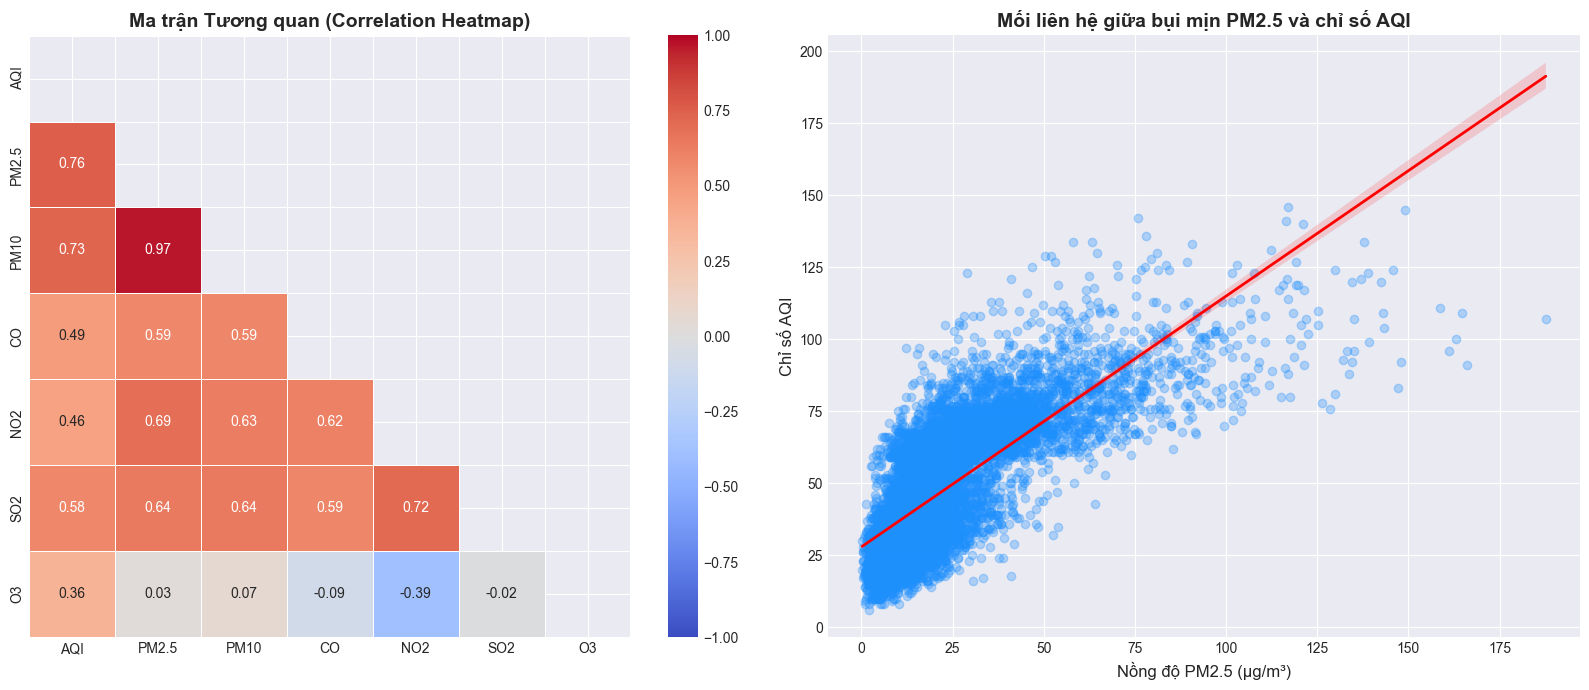

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- BIỂU ĐỒ 7: MA TRẬN TƯƠNG QUAN (HEATMAP) ---
# Chọn ra các cột cần tính tương quan
pollutants = ['AQI', 'PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3']
correlation_matrix = df[pollutants].corr()

# Vẽ Heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Che nửa trên của ma trận cho gọn
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, square=True, linewidths=.5, ax=axes[0])
axes[0].set_title('Ma trận Tương quan (Correlation Heatmap)', fontsize=14, fontweight='bold')

# --- BIỂU ĐỒ 8: SCATTER PLOT GIỮA PM2.5 VÀ AQI ---
# Vẽ biểu đồ phân tán kèm đường hồi quy tuyến tính (Regression Line)
# Trích xuất 10,000 mẫu ngẫu nhiên (sample) để vẽ nhanh hơn vì dữ liệu lớn
sample_df = df.sample(n=10000, random_state=42)

sns.regplot(x='PM2.5', y='AQI', data=sample_df, ax=axes[1], 
            scatter_kws={'alpha':0.3, 'color':'dodgerblue'}, line_kws={'color':'red', 'linewidth':2})
axes[1].set_title('Mối liên hệ giữa bụi mịn PM2.5 và chỉ số AQI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nồng độ PM2.5 (µg/m³)', fontsize=12)
axes[1].set_ylabel('Chỉ số AQI', fontsize=12)

plt.tight_layout()
plt.show()


**Phân tích Thống kê Tương quan Đa biến và Xác định Yếu tố Quyết định AQI (Pollutant Correlation)**

**1. Phân tích Tương quan Tuyến tính (Pearson Correlation Matrix):**
*   **Hệ số tương quan (r) với biến phụ thuộc (AQI):** Phân tích ma trận tương quan cho thấy vật chất hạt có rủi ro tác động lớn nhất đến chỉ số AQI tổng hợp. Cụ thể, hệ số tương quan tuyến tính giữa PM2.5 và AQI đạt mức rất cao (r = 0.76), theo sát là PM10 (r = 0.73). Các khí thải (SO2, CO, NO2) có mức độ tương quan trung bình (r dao động từ 0.46 đến 0.58), trong khi O3 có độ tương quan yếu nhất (r = 0.36).
*   **Đa cộng tuyến giữa các biến độc lập:** Tồn tại sự tương quan gần như tuyệt đối giữa PM2.5 và PM10 (r = 0.97). Điều này chỉ ra hiện tượng cộng tuyến mạnh, xác nhận hai loại bụi này phần lớn có chung nguồn gốc phát thải hoặc chịu sự chi phối của cùng các cơ chế vật lý khí quyển. 
*   **Phản ứng quang hóa của Ozone:** Ma trận ghi nhận tương quan nghịch có ý nghĩa thống kê giữa O3 và NO2 (r = -0.39) cũng như CO (r = -0.09). Đây là hiện tượng đặc trưng trong hóa học khí quyển, phản ánh quá trình chuẩn độ Ozone nơi khí NO phản ứng và làm suy giảm nồng độ O3 tại các khu vực có nguồn phát thải giao thông cao.

**2. Phân tích Mô hình Hồi quy Tuyến tính Đơn biến (Linear Regression - Scatter Plot):**
*   **Tính chất tuyến tính:** Đồ thị phân tán mô tả mối quan hệ trực tiếp giữa biến độc lập (PM2.5) và biến phụ thuộc (AQI). Đường hồi quy tuyến tính màu đỏ có hệ số góc dương lớn, thể hiện sự gia tăng tỷ lệ thuận mạnh mẽ: sự biến thiên của nồng độ PM2.5 giải thích phần lớn sự biến thiên của chỉ số AQI.
*   **Phân phối phần dư:** Mức độ phân tán của các điểm dữ liệu xung quanh đường hồi quy hẹp lại đáng kể khi nồng độ PM2.5 tăng cao. Điều này chứng minh rằng ở các mốc chất lượng không khí từ mức Trung bình trở xuống, AQI có thể bị chi phối bởi nhiều yếu tố khác nhau (khí thải O3, SO2), nhưng khi xảy ra các sự kiện ô nhiễm nghiêm trọng, PM2.5 gần như là biến số duy nhất quyết định giá trị cực đại của AQI.
*   **Kết luận định lượng:** Dữ liệu thống kê khẳng định vật chất hạt mịn (PM2.5) là tác nhân định lượng chủ đạo chi phối mức độ ô nhiễm không khí tại Việt Nam, vượt trội hoàn toàn so với các chỉ tiêu khí vô cơ khác trong rổ tính toán AQI.


**KẾT LUẬN TỔNG THỂ**

Dựa trên quá trình phân tích khám phá dữ liệu (EDA) toàn diện về không gian, thời gian và sự tương quan cấu trúc của các chỉ số chất lượng không khí, báo cáo rút ra các kết luận định lượng trọng tâm sau:

1.  **Về thực trạng tổng thể:** Tuyệt đại đa số thời gian quan trắc (98.4%) chất lượng không khí trên hệ thống duy trì ở mức độ an toàn (Tốt và Trung bình). Tuy nhiên, đặc tính phân phối lệch phải của đồ thị tần suất cảnh báo về rủi ro của các đợt ô nhiễm cục bộ có cường độ cao, dẫu tần suất xuất hiện thấp.
2.  **Về tính chu kỳ thời gian:** Chu kỳ biến thiên nồng độ vật chất hạt trong ngày thể hiện rõ đặc tính đa đỉnh, tương quan chặt chẽ với động lực học của lớp biên hành tinh và nhịp độ giao thông nhân sinh (đỉnh điểm vào sáng sớm và chiều tối). Trái lại, phương sai giữa các ngày trong tuần không có ý nghĩa thống kê, cho thấy sự duy trì liên tục của mức nền ô nhiễm cơ sở.
3.  **Về sự phân hóa không gian:** Tồn tại sự chênh lệch có ý nghĩa thống kê về rủi ro môi trường giữa các vùng sinh thái. Miền Bắc hiện đang chịu tải lượng ô nhiễm cao nhất với trung vị AQI và độ phân tán phương sai vượt trội so với Miền Nam và Miền Trung.
4.  **Về tác nhân định lượng chủ đạo:** Phân tích ma trận đa cộng tuyến và hồi quy tuyến tính khẳng định vật chất hạt mịn (đặc biệt là PM2.5) là biến số độc lập mang tính quyết định chi phối trực tiếp đến sự biến thiên của chỉ số AQI tổng hợp, làm lu mờ tác động của các khí vô cơ khác trong các sự kiện ô nhiễm nghiêm trọng.

**Hàm ý Quản lý Môi trường:**
Hệ quả từ dữ liệu thống kê chỉ ra rằng, để tối ưu hóa hiệu quả cải thiện chất lượng không khí, các nỗ lực hoạch định chính sách và phân bổ nguồn lực cần được tập trung vào **hai trọng tâm cốt lõi**: (1) ưu tiên kiểm soát triệt để các nguồn phát thải PM2.5; và (2) tập trung các biện pháp can thiệp rủi ro vào các vùng lõi đô thị tại Miền Bắc, đặc biệt là trong các khung giờ cao điểm có nghịch nhiệt.
